# Rapalog Discovery Pipeline
## 04 Similarity prediction notebook
### **Phase 4: Supervised Regression (Predicting Similarity from Chemistry Features)**
A. Create regression dataframe
B. Regression scaling
C. Regression predictions
D. Regression evaluation
E. Regression diagnostic plots
F. Regression feature coefficients
G. Baseline feature weights
H. Residual error outliers on PCA

In [1]:
# P4 setup: import similarity modeling helpers
import sys
import importlib
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import similarity_model
similarity_model = importlib.reload(similarity_model)

from src.similarity_model import (
    prepare_similarity_dataset,
    train_similarity_model,
    evaluate_similarity_model,
    plot_similarity_diagnostics,
    feature_importance_similarity,
)

results_dir = PROJECT_ROOT / "results" / "notebook_04"
results_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results dir:", results_dir)

Project root: /Users/alangale/Projects/rapalog-discovery-pipeline
Results dir: /Users/alangale/Projects/rapalog-discovery-pipeline/results/notebook_04


In [2]:
# P4.A-P4.D Prepare data, train, and evaluate model
X_train, X_test, y_train, y_test = prepare_similarity_dataset()

model = train_similarity_model(X_train, y_train)

metrics = evaluate_similarity_model(
    model,
    X_test,
    y_test,
    results_dir=results_dir,
    metrics_filename="similarity_model_metrics.csv",
)

print(f"R2: {metrics['r2']:.4f}")
print(f"RMSE: {metrics['rmse']:.4f}")
print(f"MAE: {metrics['mae']:.4f}")
print(f"Range-normalized MAE (%): {metrics['range_normalized_mae_pct']:.2f}%")

y_pred = metrics["y_pred"]

[13:03:35] WARNING: not removing hydrogen atom without neighbors


R2: 0.5344
RMSE: 0.0494
MAE: 0.0388
Range-normalized MAE (%): 6.15%


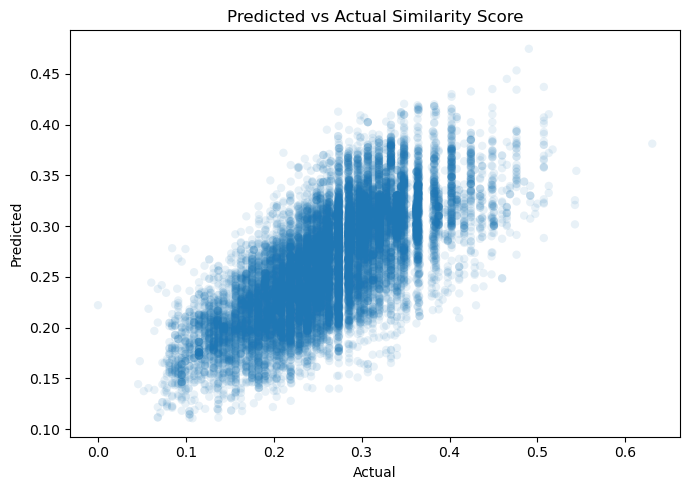

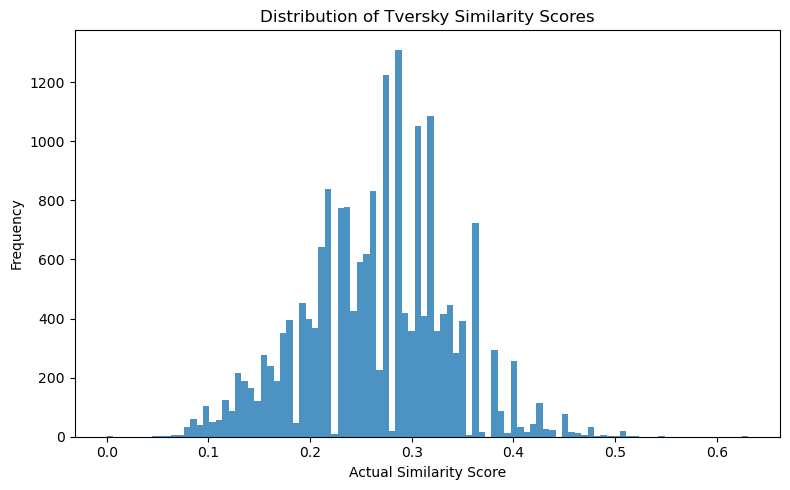

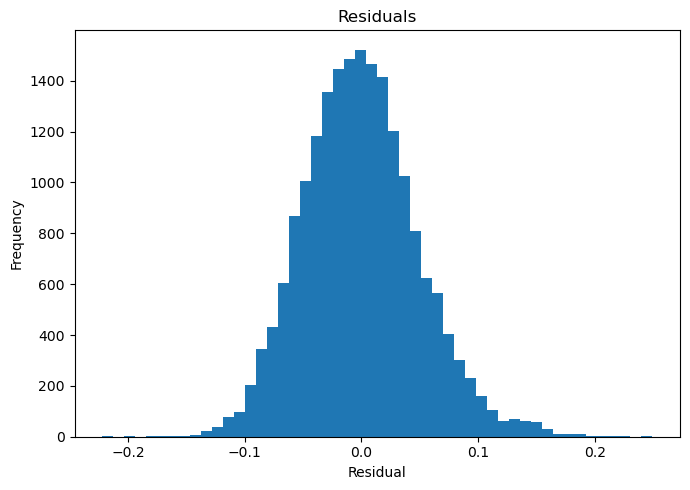

Saved diagnostics:
- similarity_pred_vs_actual.png
- similarity_actual_distribution.png
- similarity_residual_histogram.png


In [3]:
# P4.E Save regression diagnostic plots
plot_similarity_diagnostics(
    y_test,
    y_pred,
    results_dir=results_dir,
 )

print("Saved diagnostics:")
print("- similarity_pred_vs_actual.png")
print("- similarity_actual_distribution.png")
print("- similarity_residual_histogram.png")

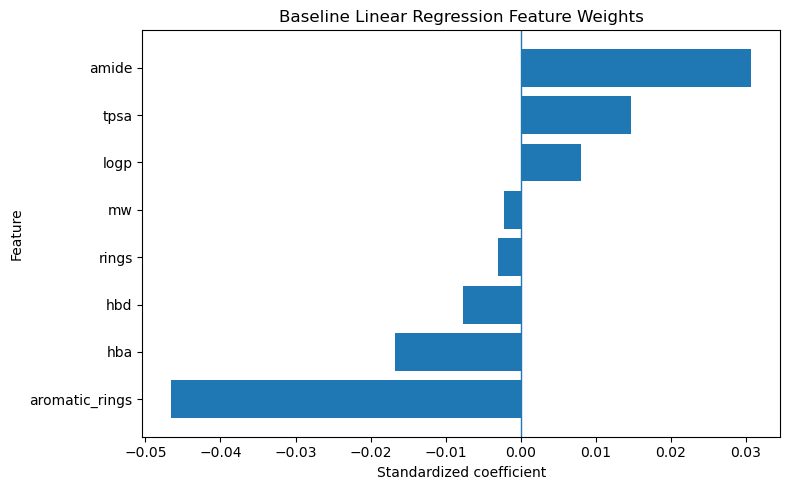

,feature,coefficient,abs_coefficient
3,aromatic_rings,-0.046540,0.046540
7,amide,0.030655,0.030655
1,hba,-0.016774,0.016774
4,tpsa,0.014694,0.014694
5,logp,0.008032,0.008032
0,hbd,-0.007760,0.007760
2,rings,-0.003073,0.003073
6,mw,-0.002215,0.002215


Saved feature outputs:
- similarity_model_coefficients.csv
- similarity_feature_weights.png


In [4]:
# P4.F-P4.G Save feature coefficients + feature-importance chart
coef_df = feature_importance_similarity(
    model,
    feature_names=X_train.columns.tolist(),
    results_dir=results_dir,
    coefficients_filename="similarity_model_coefficients.csv",
)

display(coef_df.head(20))

print("Saved feature outputs:")
print("- similarity_model_coefficients.csv")
print("- similarity_feature_weights.png")